# Line detection with Hough Transform
The Hough Transform is a popular technique in computer vision and image processing, used for detecting geometric shapes like lines, circles, and other parametric curves. Named after Paul Hough, who introduced the concept in 1962, the transform has evolved and found numerous applications in various domains such as medical imaging, robotics, and autonomous driving.



Import libraries

In [2890]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import random
import os

Read images

In [2891]:
imgs = []
for filename in os.listdir("./images/batch02"):
    imgs.append(cv.imread(f"./images/batch02/{filename}", cv.IMREAD_GRAYSCALE))

imgs = np.array(imgs)

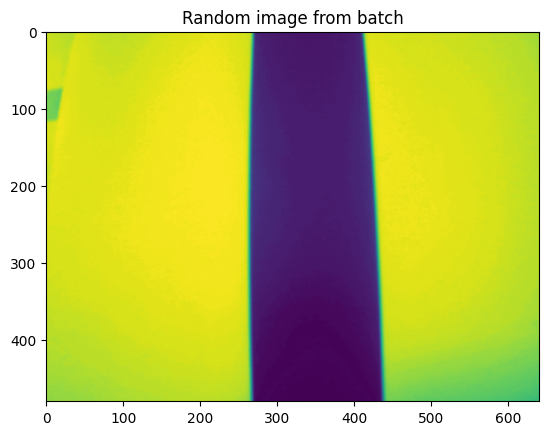

In [2892]:
random_img = np.copy(random.choice(imgs))
plt.imshow(random_img)
plt.title("Random image from batch")
plt.show()

Blurr image

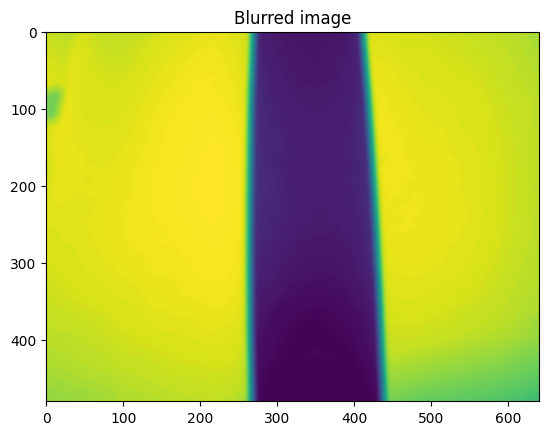

In [2893]:
FIRST_K_SIZE = (15, 15)
blurred_img = cv.blur(random_img, ksize=FIRST_K_SIZE)
plt.imshow(blurred_img)
plt.title("Blurred image")
plt.show()

Canny edge detection

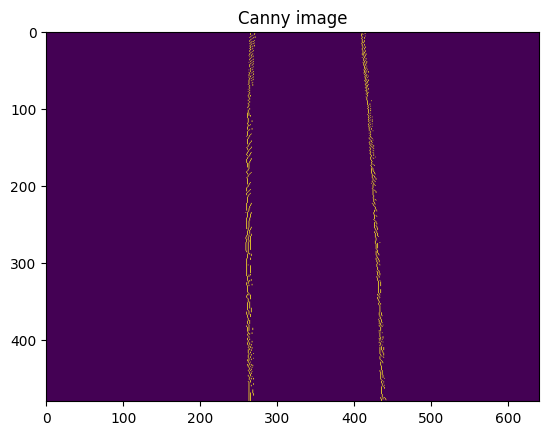

In [2894]:
THRES_LOW_EDGES = 40
THRES_HIGH_EDGES = 45
canny_img = cv.Canny(blurred_img, THRES_LOW_EDGES, THRES_HIGH_EDGES)
plt.imshow(canny_img)
plt.title("Canny image")
plt.show()

Apply second blurr

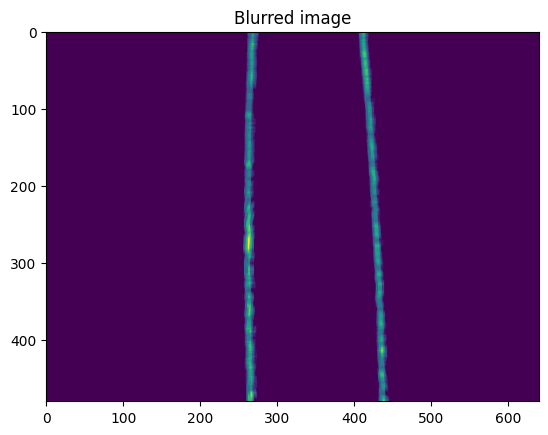

In [2895]:
SECOND_K_SIZE = (8, 8)
blurred_canny_img = cv.blur(canny_img, ksize=SECOND_K_SIZE)
plt.imshow(blurred_canny_img)
plt.title("Blurred image")
plt.show()

Detect lines using Hough Transform

In [2896]:
RHO = 1
THETA = np.pi / 180
THRESHOLD = 40
MIN_LINE_LEN = 50
lines = cv.HoughLinesP(blurred_canny_img, RHO, THETA, THRESHOLD, minLineLength=MIN_LINE_LEN)

In [2897]:
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv.line(random_img, (x1, y1), (x2, y2), (255, 0, 0), 2)

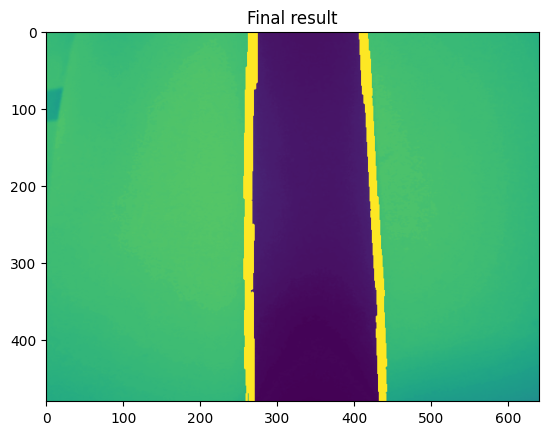

In [2898]:
plt.imshow(random_img)
plt.title("Final result")
plt.show()

In [2899]:
def process_img(img):
    # First blurr
    blurred_img = cv.blur(img, ksize=FIRST_K_SIZE)

    # Canny edge detection
    canny_img = cv.Canny(blurred_img, THRES_LOW_EDGES, THRES_HIGH_EDGES)

    # Second blurr
    blurred_canny_img = cv.blur(canny_img, ksize=SECOND_K_SIZE)

    # Hough Transform
    lines = cv.HoughLinesP(blurred_canny_img, RHO, THETA, THRESHOLD, minLineLength=MIN_LINE_LEN)

    # Draw lines
    img_copy = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(img_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    # Compute average x position of the line
    lines = lines.reshape(-1, 4)
    avg_x = np.average((lines[:, 0] + lines[:, 2]) / 2)
    avg_y = np.average((lines[:, 1] + lines[:, 3]) / 2)

    # Draw line
    height, width = img.shape

    cv.line(img_copy, (int(width/2), int(height)), (int(avg_x), int(avg_y)), (000, 255, 0), 2)
    
    return img_copy

Text(0.5, 1.0, 'Detected lines')

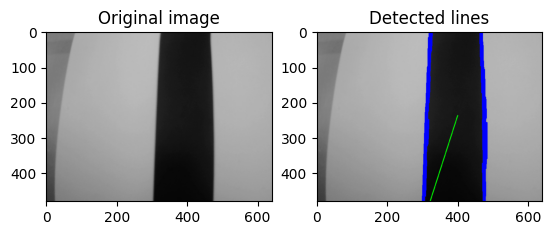

In [2951]:
original_img = random.choice(imgs)
res_img = process_img(original_img)

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original_img, cv.COLOR_BGR2RGB))
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(res_img, cv.COLOR_BGR2RGB))
plt.title("Detected lines")